<a href="https://colab.research.google.com/github/Gu1-Fr4nc0/Reconhecimento_de_Expressoes_Faciais_com_Redes_Neurais_Convolucionais/blob/main/ProjetoSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, zipfile, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
zip_path = "/content/drive/MyDrive/datasets/archive.zip"  # ajuste
extract_path = "/content/fer2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
!ls {extract_path}

test  train


In [ ]:
KEEP_CLASSES = ['angry', 'happy', 'neutral', 'sad', 'surprise']

base_path = "/content/fer2013"
new_base_path = "/content/fer2013_filtered"

# Se o ls acima mostrar uma subpasta a mais (ex: /content/fer2013/fer2013/train),
# ajuste base_path para apontar para onde estão as pastas train/ e test/.

if os.path.exists(new_base_path):
    shutil.rmtree(new_base_path)

for split in ['train', 'test']:
    for cls in KEEP_CLASSES:
        src = os.path.join(base_path, split, cls)
        dst = os.path.join(new_base_path, split, cls)
        if os.path.exists(src):
            shutil.copytree(src, dst)
        else:
            print(f"Aviso: {src} não encontrado")

print("Filtrado em:", new_base_path)

Filtrado em: /content/fer2013_filtered


In [ ]:
IMG_SIZE = 48          # tamanho nativo do FER2013, não precisa esticar
BATCH_SIZE = 64

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(new_base_path, "train"),
    label_mode='categorical',
    color_mode='grayscale',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(new_base_path, "test"),
    label_mode='categorical',
    color_mode='grayscale',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 24176 files belonging to 5 classes.
Found 6043 files belonging to 5 classes.
Classes: ['angry', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
y_train = []
for _, labels in train_ds:
    y_train.extend(np.argmax(labels.numpy(), axis=1))
y_train = np.array(y_train)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Peso por classe:", class_weight_dict)

Peso por classe: {0: np.float64(1.2103128911138923), 1: np.float64(0.6701593901593902), 2: np.float64(0.9738569989929506), 3: np.float64(1.0010766045548654), 4: np.float64(1.52481866918953)}


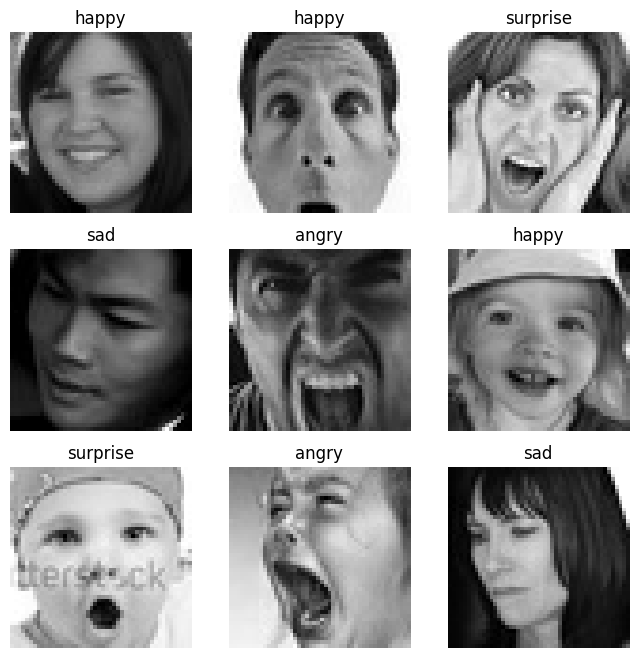

In [ ]:
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap='gray')
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,509,701 (13.39 MB)

 Trainable params: 3,507,397 (13.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 44s 73ms/step - accuracy: 0.2961 - loss: 1.8117 - val_accuracy: 0.2625 - val_loss: 1.5956 - learning_rate: 0.0010
Epoch 2/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.4392 - loss: 1.3593 - val_accuracy: 0.4941 - val_loss: 1.2063 - learning_rate: 0.0010
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5304 - loss: 1.1594 - val_accuracy: 0.5838 - val_loss: 1.0281 - learning_rate: 0.0010
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5721 - loss: 1.0761 - val_accuracy: 0.5598 - val_loss: 1.0820 - learning_rate: 0.0010
Epoch 5/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5955 - loss: 1.0239 - val_accuracy: 0.6119 - val_loss: 0.9675 - learning_rate: 0.0010
Epoch 6/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.6110 - loss: 0.9920 - val_accuracy: 0.5883 - val_loss: 1.0041 - learning_rate: 0.0010
Epoch 7/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.6248 - l

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7104 - loss: 0.7507
Acurácia no teste: 0.7104


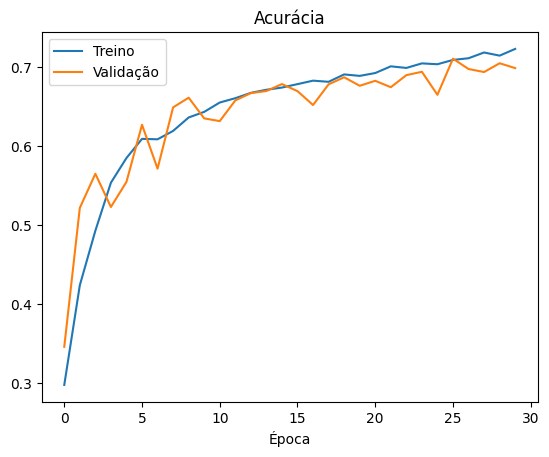

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Acurácia no teste: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia'); plt.xlabel('Época'); plt.legend(); plt.show()

model.save("/content/fer2013_model.keras")

In [ ]:
def detect_face_and_emotion(image_path):
    # Carrega imagem colorida
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detecta rosto com OpenCV (Haar Cascade)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(48,48))

    if len(faces) == 0:
        print("Nenhum rosto detectado.")
        return

    for (x,y,w,h) in faces:
        # Recorta o rosto
        face = gray[y:y+h, x:x+w]
        # Redimensiona para 48x48
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        # Normaliza e adiciona dimensões (batch, altura, largura, canal)
        face_input = face_resized / 255.0
        face_input = face_input.reshape(1, IMG_SIZE, IMG_SIZE, 1)

        # Prediz
        pred = model.predict(face_input, verbose=0)
        emotion = class_names[np.argmax(pred)]
        confidence = np.max(pred)

        # Desenha retângulo e texto na imagem original
        cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img_rgb, f"{emotion} ({confidence:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

    plt.figure(figsize=(8,6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [ ]:
def detect_face_and_emotion(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(48,48))

    if len(faces) == 0:
        print("Nenhum rosto detectado.")
        return

    for (x,y,w,h) in faces:
        face = gray[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_input = (face_resized / 255.0).reshape(1, IMG_SIZE, IMG_SIZE, 1)  # 1 canal

        pred = model.predict(face_input, verbose=0)
        emotion = class_names[np.argmax(pred)]
        confidence = np.max(pred)

        cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img_rgb, f"{emotion} ({confidence:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

    plt.figure(figsize=(8,6)); plt.imshow(img_rgb); plt.axis('off'); plt.show()

In [ ]:
y_true, y_pred, y_prob = [], [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [ ]:
top2 = np.mean([t in np.argsort(p)[-2:] for t, p in zip(y_true, y_prob)])
print(f"Top-1 accuracy: {np.mean(y_true == y_pred):.4f}")
print(f"Top-2 accuracy: {top2:.4f}")

Top-1 accuracy: 0.7104
Top-2 accuracy: 0.8842


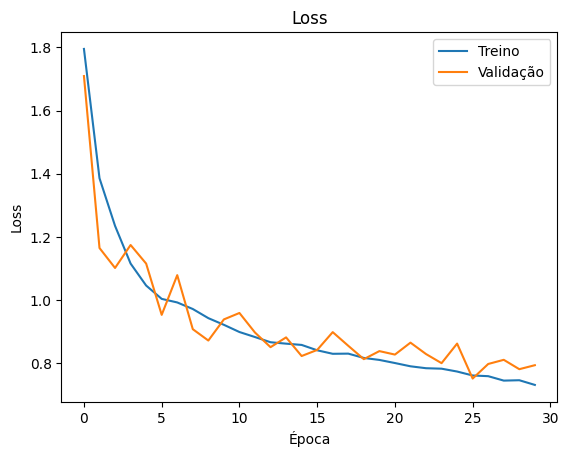

In [ ]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss'); plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend()
plt.show()

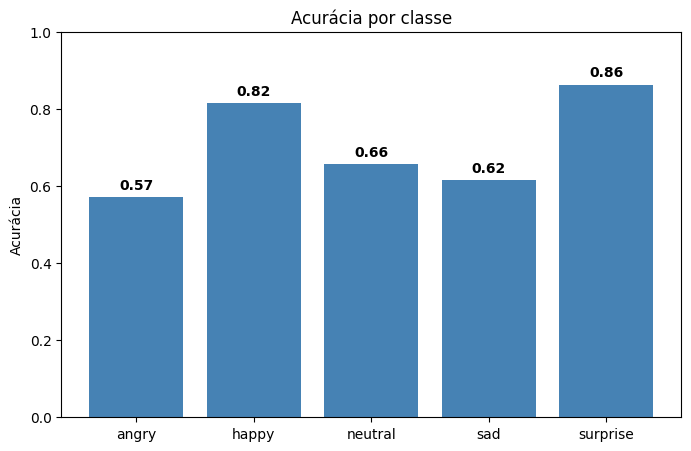

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8,5))
bars = plt.bar(class_names, per_class_acc, color='steelblue')
plt.ylim(0, 1)
plt.title('Acurácia por classe'); plt.ylabel('Acurácia')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.2f}",
             ha='center', fontweight='bold')
plt.show()

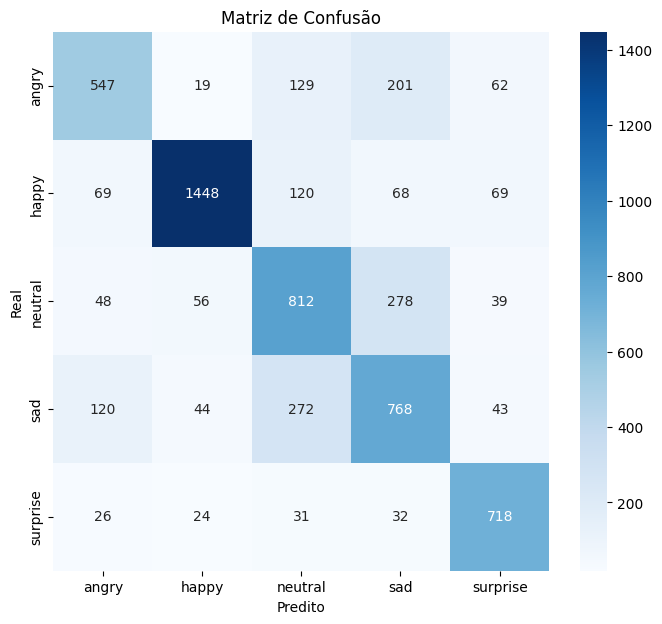

              precision    recall  f1-score   support

       angry      0.675     0.571     0.619       958
       happy      0.910     0.816     0.861      1774
     neutral      0.595     0.659     0.625      1233
         sad      0.570     0.616     0.592      1247
    surprise      0.771     0.864     0.815       831

    accuracy                          0.710      6043
   macro avg      0.704     0.705     0.702      6043
weighted avg      0.719     0.710     0.713      6043



In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predito'); plt.ylabel('Real'); plt.title('Matriz de Confusão')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Saving felicidade.jpeg to felicidade (1).jpeg


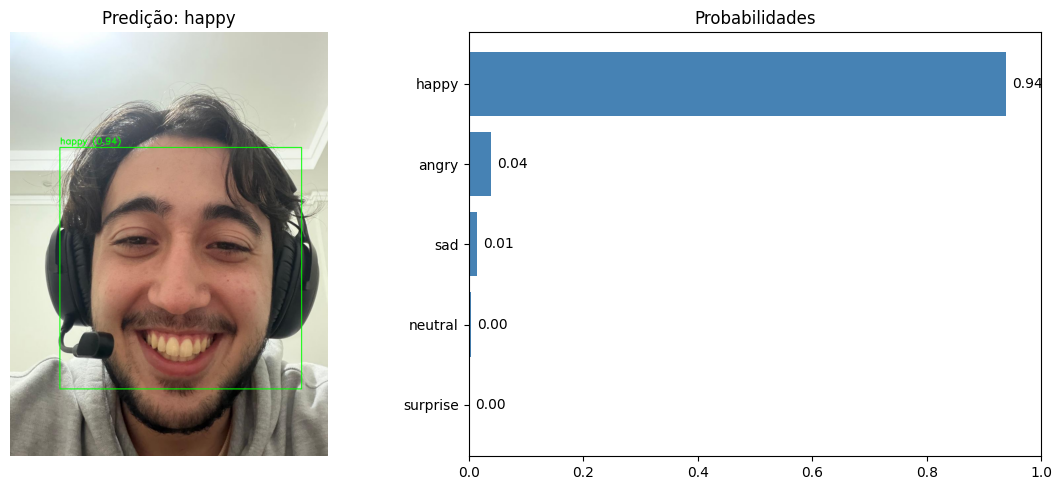

In [ ]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt

def detectar_emocao(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Não consegui ler a imagem."); return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 8, minSize=(80,80))

    # se não achar rosto, usa a imagem inteira como fallback
    if len(faces) == 0:
        print("Nenhum rosto detectado — usando a imagem inteira.")
        faces = [(0, 0, gray.shape[1], gray.shape[0])]

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_input = (face_resized / 255.0).reshape(1, IMG_SIZE, IMG_SIZE, 1)

        pred = model.predict(face_input, verbose=0)[0]
        idx = np.argmax(pred)
        emotion, conf = class_names[idx], pred[idx]

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img_rgb, f"{emotion} ({conf:.2f})", (x, max(y-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # imagem + barra de probabilidades lado a lado
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.imshow(img_rgb); ax1.axis('off'); ax1.set_title(f"Predição: {emotion}")

        ordem = np.argsort(pred)
        ax2.barh([class_names[i] for i in ordem], pred[ordem], color='steelblue')
        ax2.set_xlim(0, 1); ax2.set_title("Probabilidades")
        for i, v in zip(range(len(ordem)), pred[ordem]):
            ax2.text(v + 0.01, i, f"{v:.2f}", va='center')
        plt.tight_layout(); plt.show()

uploaded = files.upload()  # escolha um .jpg ou .png
for filename in uploaded.keys():
    detectar_emocao(filename)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

# Coleta todas as predições e rótulos verdadeiros do conjunto de validação
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcula as métricas por classe
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=range(len(class_names)))

# Exibe os resultados
print("Métricas por Classe (Corretas):")
print("-" * 70)
print(f"{'Classe':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Suporte':<10}")
print("-" * 70)
for i, name in enumerate(class_names):
    print(f"{name:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
print("-" * 70)
print(f"Média Macro: Precision={precision.mean():.4f}, Recall={recall.mean():.4f}, F1={f1.mean():.4f}")

Métricas por Classe (Corretas):
----------------------------------------------------------------------
Classe       Precision    Recall       F1-Score     Suporte   
----------------------------------------------------------------------
angry        0.6488       0.6190       0.6335       958       
happy        0.8640       0.8557       0.8598       1774      
neutral      0.6009       0.6740       0.6353       1233      
sad          0.6259       0.5742       0.5989       1247      
surprise     0.8296       0.8436       0.8365       831       
----------------------------------------------------------------------
Média Macro: Precision=0.7138, Recall=0.7133, F1=0.7128


In [ ]:
!pip install shap
import shap

In [ ]:
# Coleta um lote de imagens do treino para usar como background
background_images = []
background_labels = []
for images, labels in train_ds.take(5):  # 5 batches de 64 = 320 imagens
    background_images.append(images.numpy())
    background_labels.append(labels.numpy())

background_images = np.concatenate(background_images, axis=0)
background_labels = np.concatenate(background_labels, axis=0)

# Pega apenas 100 imagens para não ficar pesado
background = background_images[:100]
print(f"Shape do background: {background.shape}")

Shape do background: (100, 48, 48, 1)


In [ ]:
# Coleta predições e labels reais do validation set
val_images = []
val_labels_true = []
val_labels_pred = []

for images, labels in val_ds.take(10):  # Pega 10 batches para ter exemplos variados
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    # Armazena apenas os que o modelo errou
    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            val_images.append(images[i].numpy())
            val_labels_true.append(true_classes[i])
            val_labels_pred.append(pred_classes[i])

print(f"Encontradas {len(val_images)} imagens com erro para analisar.")

Encontradas 246 imagens com erro para analisar.


In [ ]:
# Cria o explainer (pode demorar um pouco)
# Usando GradientExplainer (funciona para redes neurais)
explainer = shap.GradientExplainer(
    model,
    background,
    local_smoothing=0.5  # Reduz ruído nas explicações
)

# Pega até 5 imagens de erro para explicar (para não demorar muito)
num_to_explain = min(5, len(val_images))
shap_values = explainer.shap_values(
    np.array(val_images[:num_to_explain]),
    ranked_outputs=len(class_names)  # Explica todas as classes
)

# O shap_values retorna: (valores_SHAP, índices_das_classes_rankeadas)
# Para cada imagem, temos os SHAP values para cada classe

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(5, 48, 48, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(50, 48, 48, 1))']
  warnings.warn(msg)



Explicação para imagem 1:
   Classe Real: angry
   Classe Prevista: sad


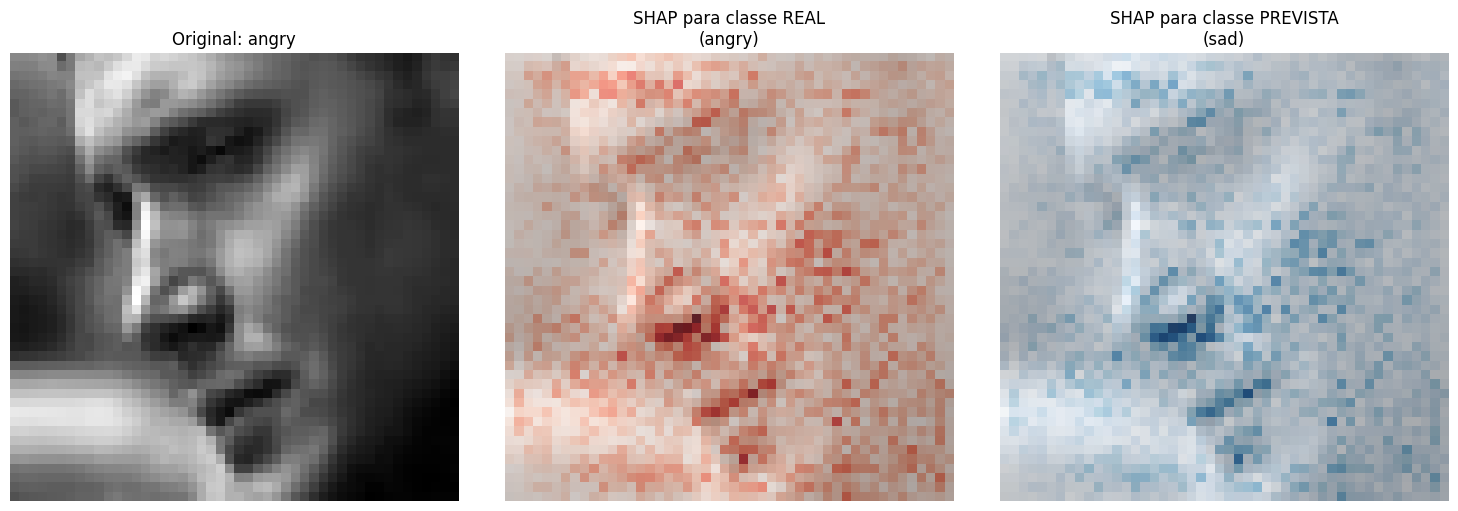


Explicação para imagem 2:
   Classe Real: angry
   Classe Prevista: sad


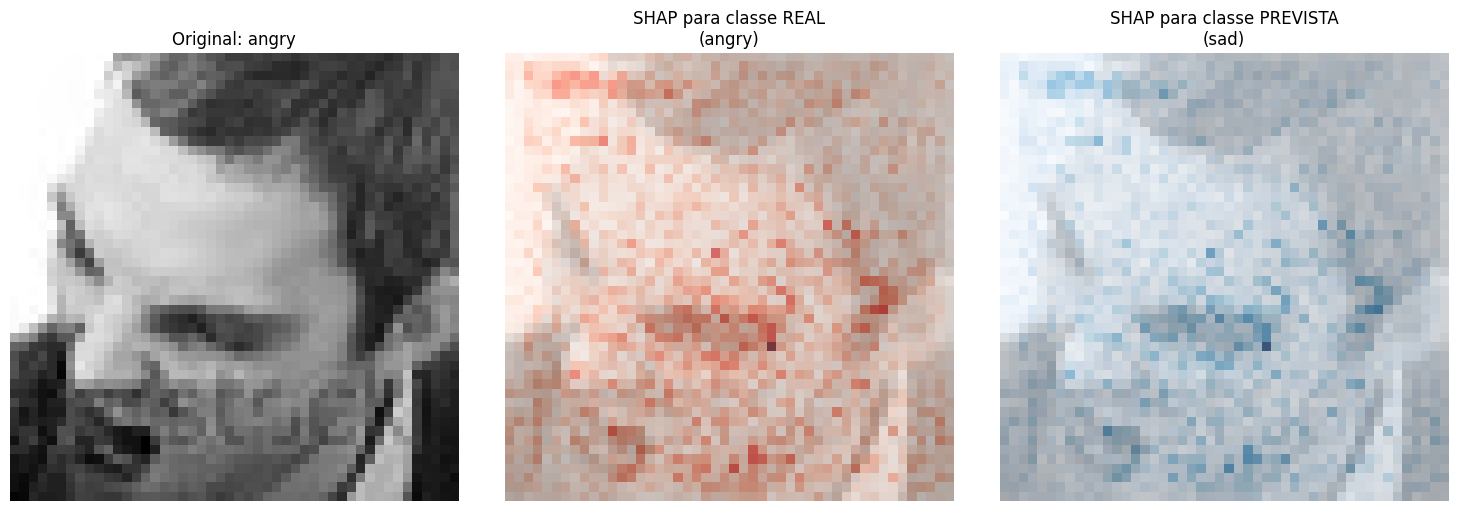


Explicação para imagem 3:
   Classe Real: angry
   Classe Prevista: surprise


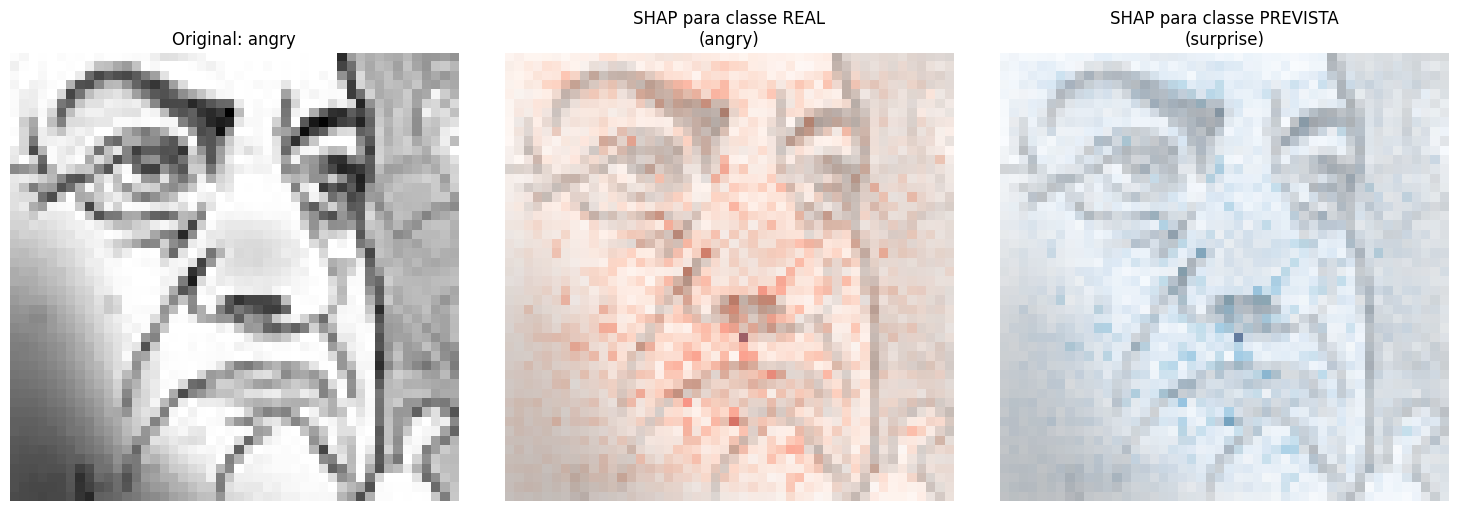


Explicação para imagem 4:
   Classe Real: angry
   Classe Prevista: neutral


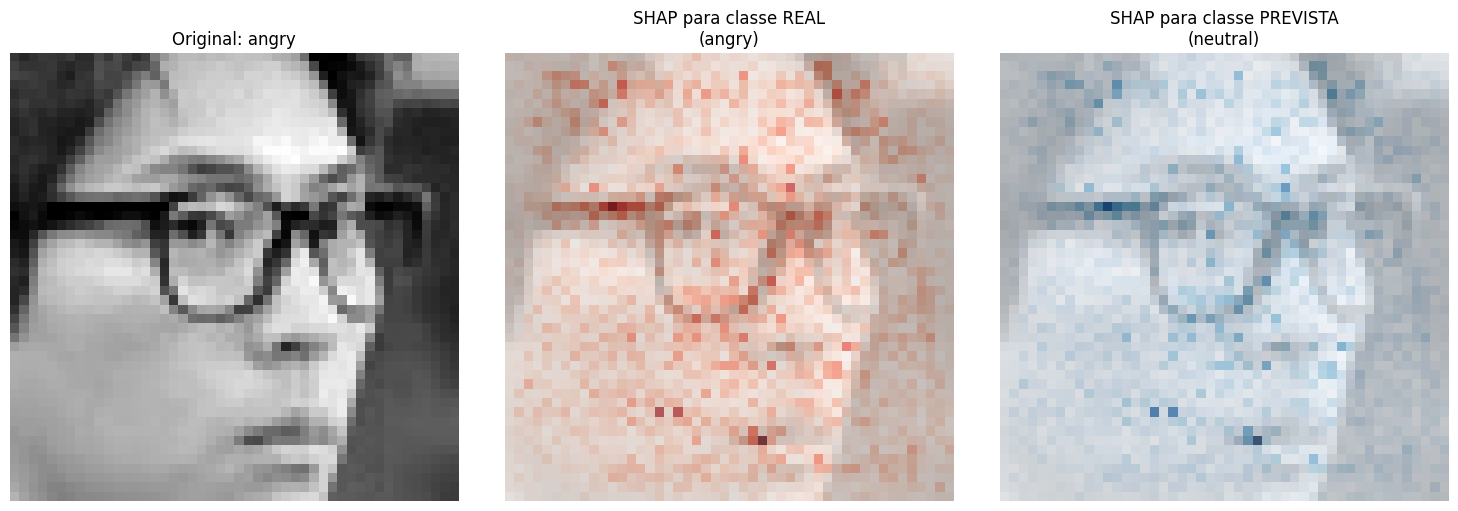


Explicação para imagem 5:
   Classe Real: angry
   Classe Prevista: neutral


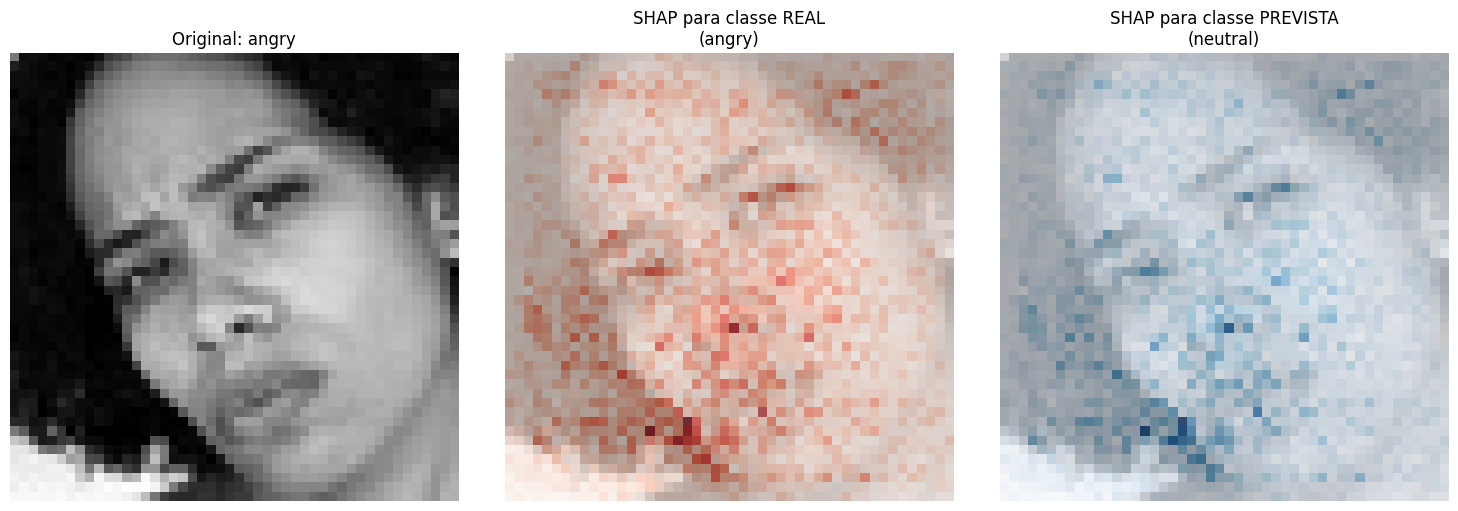

In [ ]:
# Visualiza as explicações para as primeiras imagens
for idx in range(num_to_explain):
    print(f"\nExplicação para imagem {idx+1}:")
    print(f"   Classe Real: {class_names[val_labels_true[idx]]}")
    print(f"   Classe Prevista: {class_names[val_labels_pred[idx]]}")

    # Pega os SHAP values para a classe real e a prevista
    # shap_values[0] = valores SHAP, shap_values[1] = índices das classes
    shap_vals_real = shap_values[0][idx, :, :]  # (48,48,3) para a classe real
    shap_vals_pred = shap_values[0][idx, :, :]  # (48,48,3) para a classe prevista

    # Mostra a imagem original e as explicações
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Imagem original
    img_display = val_images[idx]
    if img_display.shape[-1] == 1:  # Se for grayscale
        img_display = img_display.squeeze()
        axes[0].imshow(img_display, cmap='gray')
    else:
        axes[0].imshow(img_display.astype(np.uint8))
    axes[0].set_title(f"Original: {class_names[val_labels_true[idx]]}")
    axes[0].axis('off')

    # SHAP para a classe REAL
    axes[1].imshow(val_images[idx].squeeze(), cmap='gray', alpha=0.8)
    # Sobreposição dos SHAP values (pixels vermelhos = ajudaram a classe real)
    shap_display = np.abs(shap_vals_real).mean(axis=-1)  # Média dos canais RGB
    axes[1].imshow(shap_display, cmap='Reds', alpha=0.6, interpolation='nearest')
    axes[1].set_title(f"SHAP para classe REAL\n({class_names[val_labels_true[idx]]})")
    axes[1].axis('off')

    # SHAP para a classe PREVISTA (erroneamente)
    axes[2].imshow(val_images[idx].squeeze(), cmap='gray', alpha=0.8)
    shap_display_pred = np.abs(shap_vals_pred).mean(axis=-1)
    axes[2].imshow(shap_display_pred, cmap='Blues', alpha=0.6, interpolation='nearest')
    axes[2].set_title(f"SHAP para classe PREVISTA\n({class_names[val_labels_pred[idx]]})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

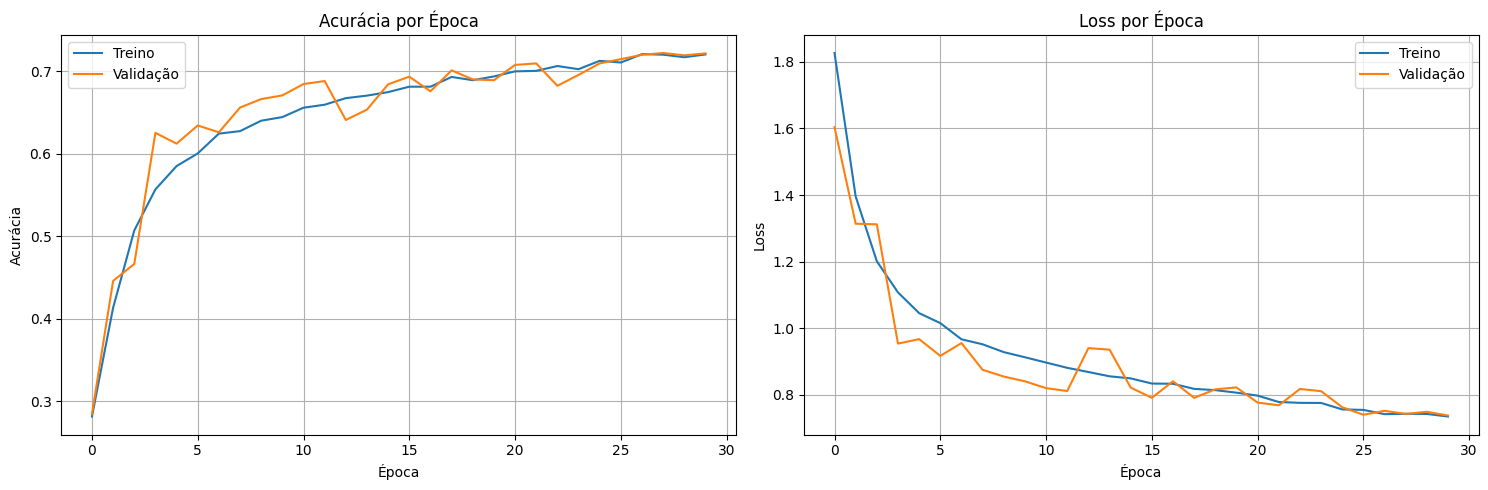

In [ ]:
# Plot das curvas de aprendizado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Acurácia
ax1.plot(history.history['accuracy'], label='Treino')
ax1.plot(history.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Treino')
ax2.plot(history.history['val_loss'], label='Validação')
ax2.set_title('Loss por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

🔍 Encontradas 219 imagens de ANGRY classificadas como ['neutral', 'surprise', 'happy'].


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(6, 48, 48, 1))']
  warnings.warn(msg)


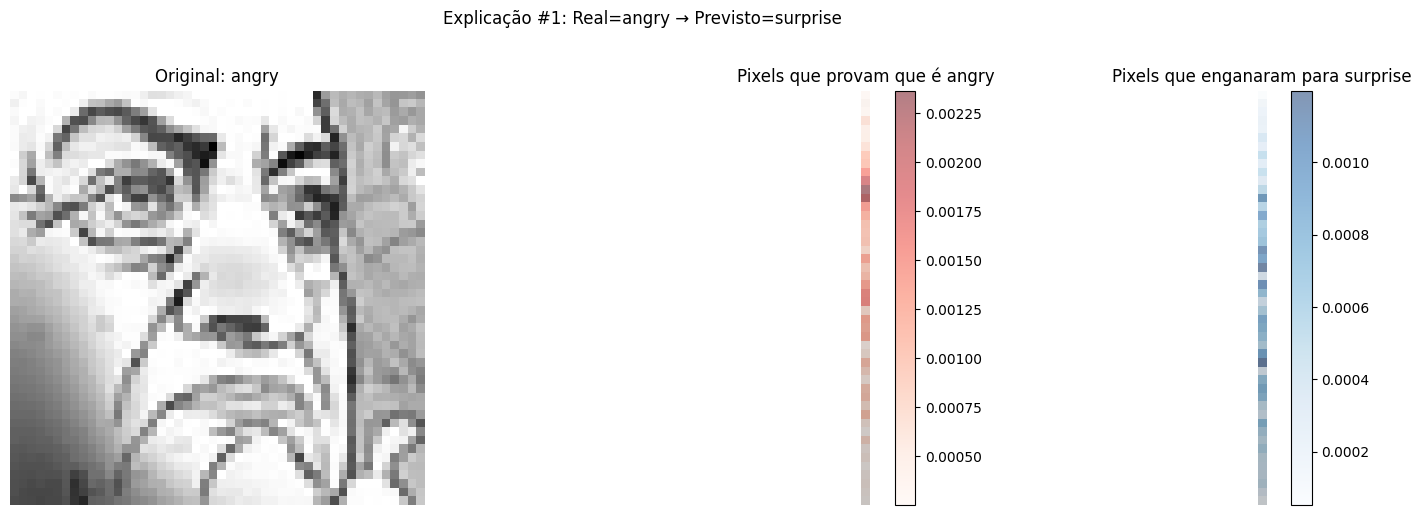

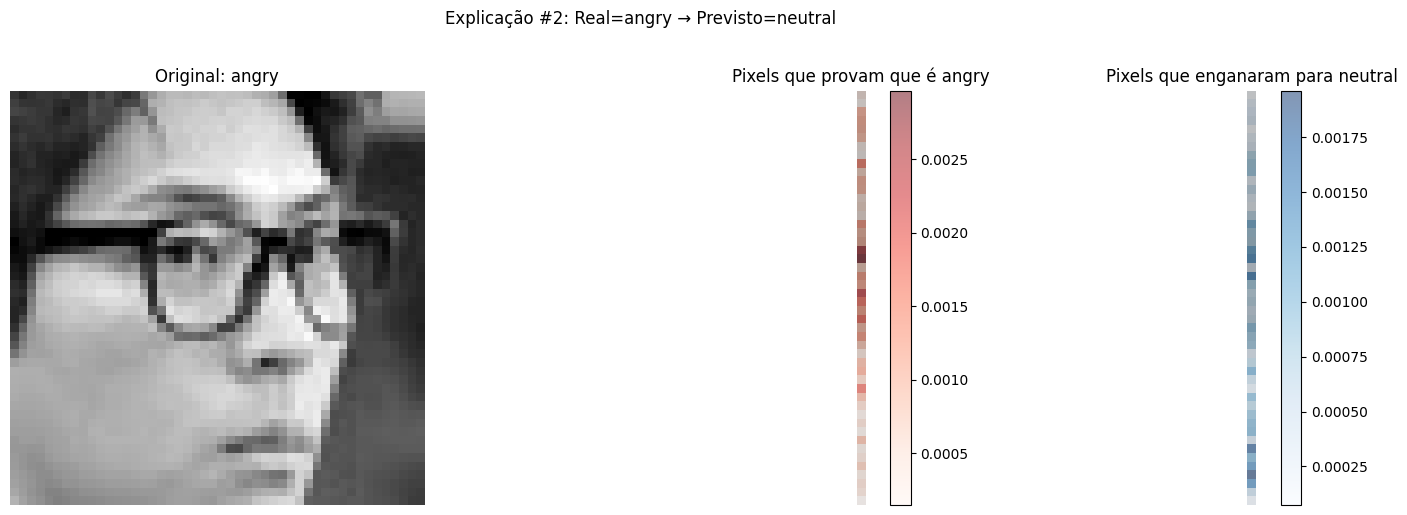

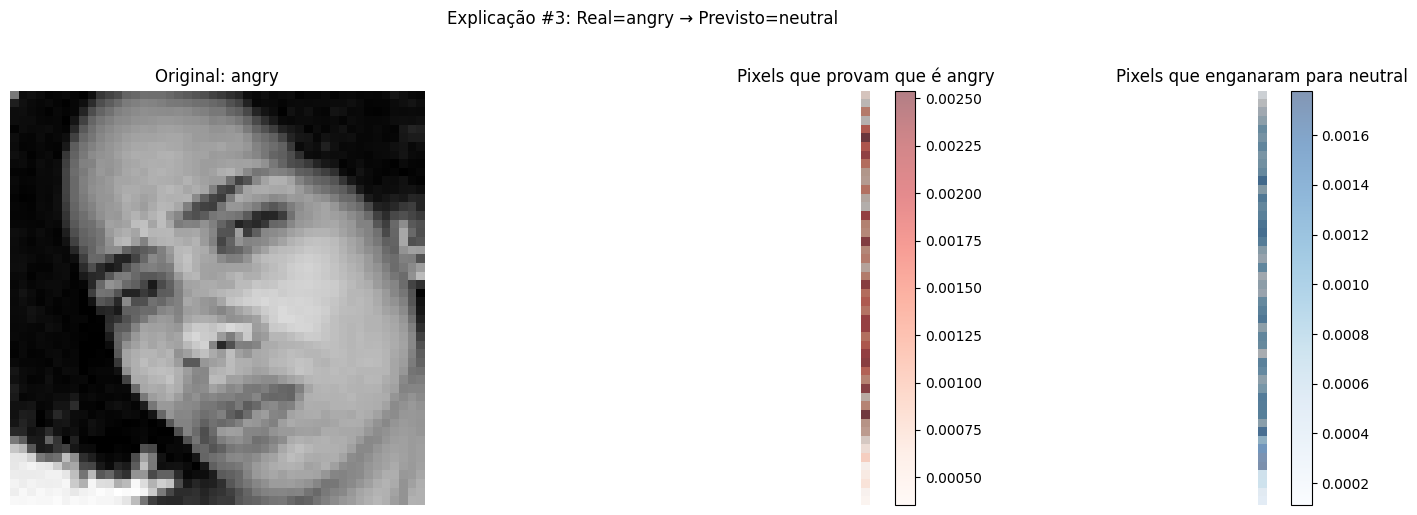

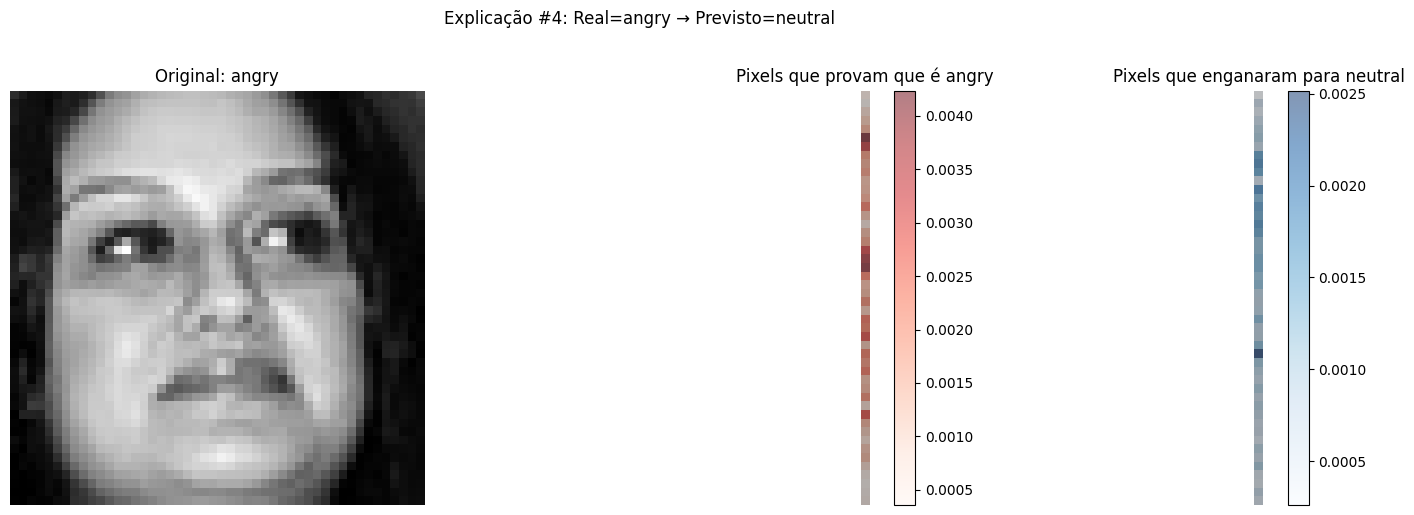

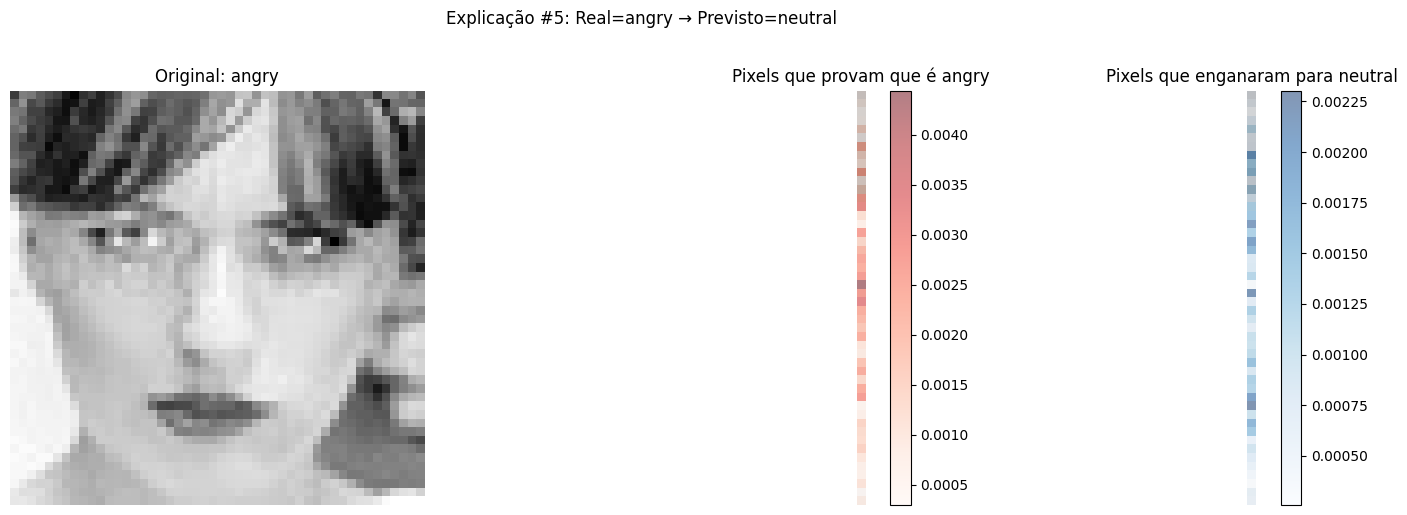

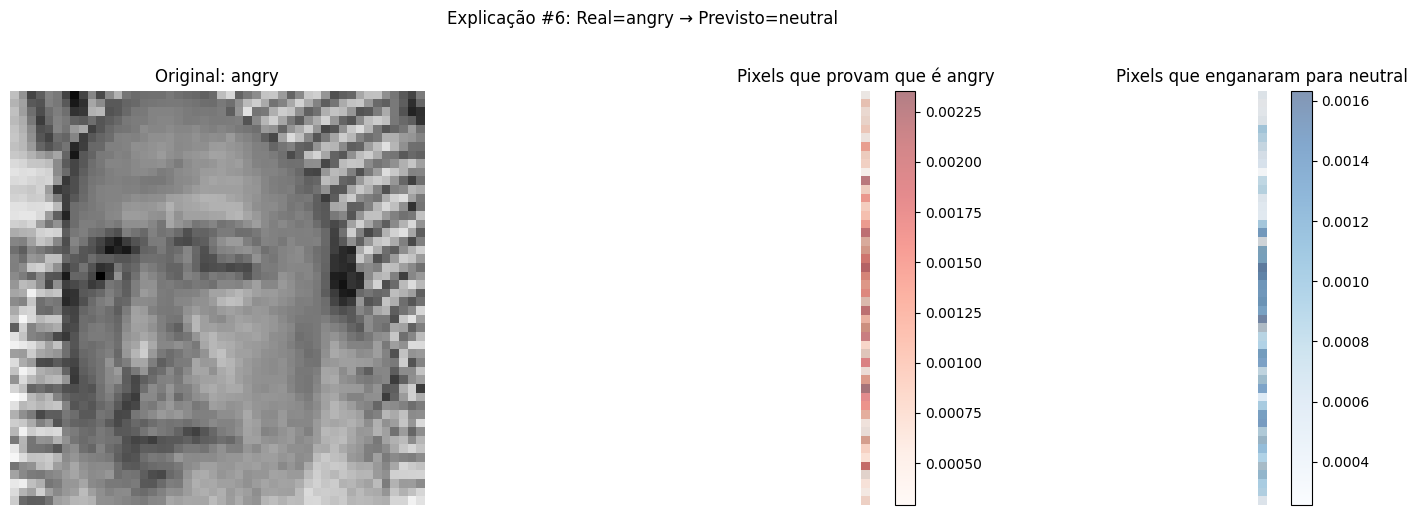

In [ ]:
# Instalação (se já fez, pode pular)
!pip install shap -q

import shap
import tensorflow as tf
import numpy as np # Ensure numpy is imported

# 1. Prepara o background (100 imagens do treino)
background_images = []
for images, _ in train_ds.take(2):  # 2 batches = 128 imagens
    background_images.append(images.numpy())
background = np.concatenate(background_images, axis=0)[:100]

# 2. Função wrapper para o SHAP (elimina os warnings) - Not directly used here, but kept for context if needed later
def model_predict(x):
    # Converte para tensor e faz a predição
    return model(tf.convert_to_tensor(x, dtype=tf.float32))

# 3. Cria o explainer (GradientExplainer é mais estável para CNNs)
# The background for GradientExplainer can be a tf.Tensor or numpy array.
# Passing it as tf.Tensor here is fine.
explainer = shap.GradientExplainer(
    model,
    tf.convert_to_tensor(background, dtype=tf.float32),
    local_smoothing=0.5
)

# 4. Filtra os erros específicos: REAL = angry, PREVISTO = {neutral, surprise, happy}
target_real = class_names.index('angry')
target_pred_errors = ['neutral', 'surprise', 'happy']
target_pred_indices = [class_names.index(cls) for cls in target_pred_errors]

error_images = []
error_true = []
error_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    true_classes = np.argmax(labels.numpy(), axis=1)
    pred_classes = np.argmax(preds, axis=1)

    for i in range(len(true_classes)):
        if true_classes[i] == target_real and pred_classes[i] in target_pred_indices:
            error_images.append(images[i].numpy()) # images[i].numpy() is already a numpy array
            error_true.append(true_classes[i])
            error_pred.append(pred_classes[i])

print(f"🔍 Encontradas {len(error_images)} imagens de ANGRY classificadas como {target_pred_errors}.")

# 5. Explica no máximo 6 dessas imagens (para não demorar)
num_to_explain = min(6, len(error_images))
if num_to_explain == 0:
    print("Nenhum erro desse tipo encontrado no lote de validação.")
else:
    # FIX: Pass a numpy array directly to shap_values.
    # The 'error_images' list already contains numpy arrays, so converting to np.array() is sufficient.
    shap_values = explainer.shap_values(
        np.array(error_images[:num_to_explain])
    )
    # The shap_values returns a list of arrays (one for each output class) or a single array
    # depending on the model output and ranked_outputs parameter.
    # The current model is multi-output (softmax for 5 classes), so it will return a list.

    # 6. Visualização personalizada
    for idx in range(num_to_explain):
        img = error_images[idx]
        true_name = class_names[error_true[idx]]
        pred_name = class_names[error_pred[idx]]

        # shap_values is a list of arrays, where each array corresponds to a class output.
        # Each array has shape (num_explained_images, height, width, channels)
        shap_real = shap_values[error_true[idx]][idx]
        shap_pred = shap_values[error_pred[idx]][idx]

        # Média dos canais (se for RGB) ou squeeze (se for grayscale)
        # The images are grayscale (48, 48, 1), so squeeze is appropriate.
        if shap_real.shape[-1] > 1:
            shap_real_vis = np.mean(np.abs(shap_real), axis=-1)
            shap_pred_vis = np.mean(np.abs(shap_pred), axis=-1)
        else:
            shap_real_vis = shap_real.squeeze()
            shap_pred_vis = shap_pred.squeeze()

        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Imagem original
        if img.shape[-1] == 1:
            axes[0].imshow(img.squeeze(), cmap='gray')
        else:
            axes[0].imshow(img.astype(np.uint8))
        axes[0].set_title(f"Original: {true_name}")
        axes[0].axis('off')

        # SHAP para a classe REAL (por que ela É angry)
        axes[1].imshow(img.squeeze(), cmap='gray', alpha=0.6)
        im1 = axes[1].imshow(shap_real_vis, cmap='Reds', alpha=0.5, interpolation='nearest')
        axes[1].set_title(f"Pixels que provam que é {true_name}")
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        # SHAP para a classe PREVISTA (por que ele achou que é {pred_name})
        axes[2].imshow(img.squeeze(), cmap='gray', alpha=0.6)
        im2 = axes[2].imshow(shap_pred_vis, cmap='Blues', alpha=0.5, interpolation='nearest')
        axes[2].set_title(f"Pixels que enganaram para {pred_name}")
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

        plt.suptitle(f"Explicação #{idx+1}: Real={true_name} → Previsto={pred_name}", y=1.02)
        plt.tight_layout()
        plt.show()

📊 Distribuição dos erros para a classe 'angry':
Previsto
neutral     147
sad         146
happy        40
surprise     32
Name: count, dtype: int64


/tmp/ipykernel_8130/1604172228.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_erros.index, y=contagem_erros.values, palette='viridis')


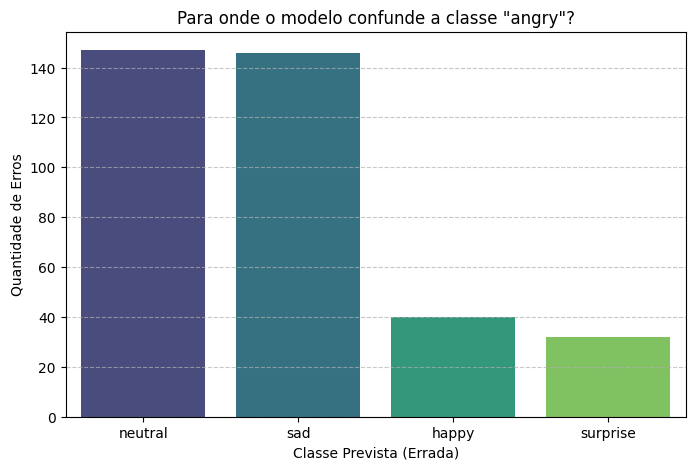

In [ ]:
import seaborn as sns
import pandas as pd

# Cria um DataFrame com os erros
erros_df = pd.DataFrame({
    'Real': [class_names[y] for y in y_true],
    'Previsto': [class_names[y] for y in y_pred]
})

# Filtra apenas os erros da classe 'angry'
erros_angry = erros_df[erros_df['Real'] == 'angry']

# Conta as previsões erradas
contagem_erros = erros_angry[erros_angry['Real'] != erros_angry['Previsto']]['Previsto'].value_counts()

print("📊 Distribuição dos erros para a classe 'angry':")
print(contagem_erros)

# Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(x=contagem_erros.index, y=contagem_erros.values, palette='viridis')
plt.title('Para onde o modelo confunde a classe "angry"?')
plt.xlabel('Classe Prevista (Errada)')
plt.ylabel('Quantidade de Erros')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()